# EgoPER video-QA inference baseline (Qwen2.5-VL)

Sanity-check a SOTA-class video LLM on EgoPER's ~10-12 min egocentric procedural videos with **user-defined questions**, and compare its free-text answers against EgoPER's ground-truth error labels (type / description / timestamp).

**Model:** `Qwen/Qwen2.5-VL-3B-Instruct` by default (4-bit nf4). The 7B OOMs on a 16 GB card shared with the display; 3B leaves headroom for the video forward. Stands in for the unavailable SlowFast-LLaVA-1.5 weights (see `README.md`).

**Memory rule (16 GB):** keep `NUM_FRAMES × MAX_PIXELS` bounded or the vision encoder OOMs. The first cell sets `expandable_segments` to reduce fragmentation — run it before anything touches CUDA.

In [7]:
import os

# must be set BEFORE torch initialises CUDA (i.e. before vqa.load_model)
os.environ.setdefault("PYTORCH_CUDA_ALLOC_CONF", "expandable_segments:True")

import sys
from pathlib import Path

# make egoper.py / vqa.py importable whether launched from repo root or egoper_vqa/
HERE = Path.cwd()
for cand in (HERE, HERE / "egoper_vqa"):
    if (cand / "egoper.py").exists():
        sys.path.insert(0, str(cand))
        break

import egoper
import vqa

print("tasks:", egoper.tasks())
print("coffee error videos:", egoper.list_videos("coffee", kind="error")[:5])
print("coffee normal videos:", egoper.list_videos("coffee", kind="normal")[:5])

tasks: ['coffee', 'pinwheels', 'oatmeal', 'quesadilla', 'tea']
coffee error videos: ['coffee_u1_a1_error_001', 'coffee_u1_a1_error_014', 'coffee_u1_a1_error_016', 'coffee_u1_a2_error_005', 'coffee_u1_a2_error_006']
coffee normal videos: ['coffee_u1_a1_normal_001', 'coffee_u1_a1_normal_002', 'coffee_u1_a1_normal_014', 'coffee_u1_a1_normal_015', 'coffee_u1_a1_normal_018']


## 1. Pick a clip and look at its ground truth

In [ ]:
TASK = "coffee"
# VIDEO_ID = egoper.list_videos(TASK, kind="error")[0]  # an error recording to start
VIDEO_ID = next((s for s in egoper.list_videos(TASK, kind="error") if "017" in s), None) # find error video 17
VIDEO = egoper.video_path(TASK, VIDEO_ID)
assert VIDEO.exists(), VIDEO

# the intended procedure (from EgoPER's task graph) — fed to the model as grounding
PROCEDURE = egoper.procedure_text(TASK)
print(PROCEDURE)
print("\n" + "=" * 80)
print(egoper.describe_gt(TASK, VIDEO_ID))  # GT for our eyes only; NOT given to the model

## 2. Sample frames (uniform baseline)

**Temporal coverage vs memory.** On 16 GB, hold `NUM_FRAMES × MAX_PIXELS` ≈ 7.4 M. This is both the SlowFast lever (more frames ↔ lower res) and the OOM guard:

| frames | max_pixels | frames×px | ≈ tokens |
|---|---|---|---|
| 32 @ 360×640 | 230400 | 7.4 M | ~4.7K |
| 64 @ 256×450 | 115200 | 7.4 M | ~4.7K (2× coverage) |
| 128 @ 256×225 | 57600 | 7.4 M | ~4.7K (SF's 128 frames) |

frames: (128, 720, 1280, 3)  | covering 0s .. 266s


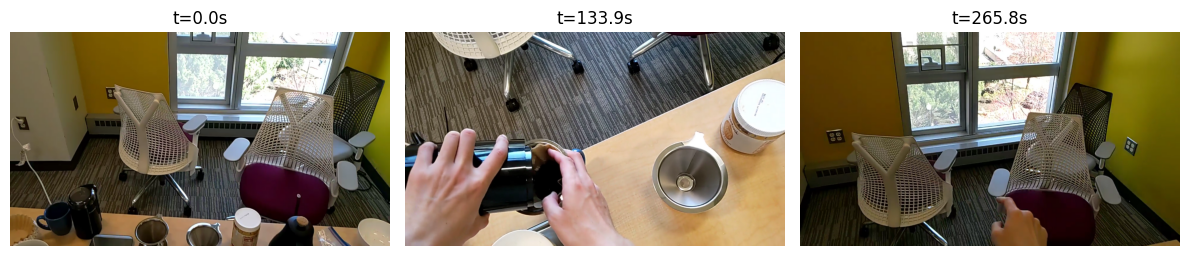

In [ ]:
NUM_FRAMES = 64
MAX_PIXELS = 256 * 450  # keep NUM_FRAMES * MAX_PIXELS ~ 7.4M on 16 GB
frames, timestamps = egoper.sample_frames(VIDEO, num_frames=NUM_FRAMES)
print(f"frames: {frames.shape}  | covering {timestamps[0]:.0f}s .. {timestamps[-1]:.0f}s")

# quick visual peek at a few sampled frames
import matplotlib.pyplot as plt

show = [0, NUM_FRAMES // 2, NUM_FRAMES - 1]
fig, axes = plt.subplots(1, len(show), figsize=(12, 4))
for ax, i in zip(axes, show):
    ax.imshow(frames[i])
    ax.set_title(f"t={timestamps[i]:.1f}s")
    ax.axis("off")
plt.tight_layout()

## 3. Load the model

Defaults to **Qwen2.5-VL-3B** — the 7B OOMs on a 16 GB card that's also driving the display. First run downloads the weights (~7 GB), 4-bit resident ~2-3 GB. The printout shows your free headroom. (Override with `vqa.load_model("Qwen/Qwen2.5-VL-7B-Instruct")` only if you've freed the GPU.)

In [10]:
model, processor = vqa.load_model()

/home/casimir/UNI/SS_26/idp/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
This can be used to load a bitsandbytes version built with a CUDA version that is different from the PyTorch CUDA version.
If this was unintended set the BNB_CUDA_VERSION variable to an empty string: export BNB_CUDA_VERSION=

Loading weights:   0%|          | 2/729 [00:00<05:42,  2.12it/s]/home/casimir/UNI/SS_26/idp/.venv/lib/python3.10/site-packages/bitsandbytes/backends/cuda/ops.py:213: FutureWarning: _check_is_size will be removed in a future PyTorch release along with guard_size_oblivious.     Use _check(i >= 0) instead.
  torch._check_is_size(blocksize)
Loading weights: 100%|██████████| 729/729 [00:09<00:00, 74.91it/s] 


loaded Qwen/Qwen2.5-VL-7B-Instruct | GPU used 7.5 / 15.5 GiB | 7.9 GiB free for the forward pass


## 4. Ask user-defined questions (uniform sampling)

Edit `QUESTIONS`. If you OOM here, lower `MAX_PIXELS` (or `NUM_FRAMES`) in §2 and re-run §2 — no model reload needed.

In [ ]:
import torch

QUESTIONS = [
    "Based on the correct procedure described above, did the person deviate from it or make any mistake? Answer yes or no, and if yes, describe exactly what went wrong.",
    "If there was a mistake, roughly when in the video did it happen and which step was being performed?",
    "Which steps of the correct procedure did you actually observe? Were any skipped, repeated, or done out of order?",
]

print(egoper.describe_gt(TASK, VIDEO_ID))
print("=" * 80)
for q in QUESTIONS:
    ans = vqa.ask(model, processor, frames, q, max_pixels=MAX_PIXELS, context=PROCEDURE)
    print(f"\nQ: {q}\nA: {ans}")
    torch.cuda.empty_cache()

## 4b. Training-free SlowFast (SF-LLaVA v1 scheme)

The genuine SlowFast-LLaVA *v1* idea — **slow** stream (few high-res frames, spatial detail) + **fast** stream (many low-res frames, temporal coverage) — applied on top of Qwen2.5-VL. No LLaVA-NeXT, no training, runs on this card.

Defaults: 16 slow @ 360×640 + 96 fast @ 200×200 ≈ 4.8K tokens (~same VRAM as the 32-frame uniform run) but **112 frames of coverage**. Keep `len(slow)*slow_px + len(fast)*fast_px` under ~7.4 M.

Compare these answers to §4: does denser coverage catch errors uniform sampling misses?

In [ ]:
N_SLOW, N_FAST = 16, 96
slow_frames, _ = egoper.sample_frames(VIDEO, num_frames=N_SLOW)
fast_frames, _ = egoper.sample_frames(VIDEO, num_frames=N_FAST)
print(f"slow={N_SLOW} hi-res + fast={N_FAST} lo-res frames")

print(egoper.describe_gt(TASK, VIDEO_ID))
print("=" * 80)
for q in QUESTIONS:
    ans = vqa.ask_slowfast(model, processor, slow_frames, fast_frames, q, context=PROCEDURE)
    print(f"\nQ: {q}\nA: {ans}")
    torch.cuda.empty_cache()

## 5. Try a normal clip (control)

A good model should *not* hallucinate errors on a correct recording.

In [ ]:
NORMAL_ID = egoper.list_videos(TASK, kind="normal")[0]
# sample the NORMAL video's own frames (earlier this reused the error clip's frames — bug)
n_slow, _ = egoper.sample_frames(egoper.video_path(TASK, NORMAL_ID), num_frames=N_SLOW)
n_fast, _ = egoper.sample_frames(egoper.video_path(TASK, NORMAL_ID), num_frames=N_FAST)
print(egoper.describe_gt(TASK, NORMAL_ID))
print("-" * 80)
print(vqa.ask_slowfast(model, processor, n_slow, n_fast, QUESTIONS[0], context=PROCEDURE))
torch.cuda.empty_cache()

## Notes / next steps

- **Memory.** OOM = lower `MAX_PIXELS` first (it cuts both vision-encoder activations and LLM tokens). Keep frames×pixels ≈ 7.4 M. If still tight, close other GPU apps (the display shares this card).
- **SlowFast vs uniform.** §4b is the training-free SF-LLaVA v1 method. If it beats §4 on subtle errors, denser coverage is the lever; tune `N_SLOW/N_FAST` and the `*_max_pixels` args in `vqa.ask_slowfast`.
- **Subtle errors.** Still missed? The lever is *where* you spend frames — sample densely around a candidate window instead of uniformly.
- **Timestamp injection.** Prepend sampled frame times to the prompt to push localization. See `CLAUDE.md` design notes.
- **Scoring.** `egoper.ground_truth(task, video_id)` returns structured `errors` (type/desc/timestamp) for a real eval loop over `list_videos(task, kind=...)`.